# **Project Name**    -Shopper Spectrum:Customer Segmentation & Product Recommendation



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual

# **Project Summary -**


The e-commerce industry The e-commerce industry generates a massive volume of transactional data dally from millions of customers around the world. This data holds inmense vakar as it refecti cartomer behaviors, perferencns, and spending pamens However, to convert this raw data into actionable insighes, we need to apply data science techniques that can intract meaninghui partent and help improve bases outcomes

In this project titled "Shopper Spectrunc Customer Segmentation and Product Recommendation", we aim to leverage customer transaction data to solve two key problems faced by online retailers

1. Customer Segmentation Grouping customers based on their purchase behavior using Recency Frequency, and Monetary analysis followed by ursupervised dustning

2. Product Recommendatione Suggesting relevant products to saers using collaborative filtering based on past purchase hinoy

The dataset used in this project contains transaction records of a UK-based online nail company, sparring across courries and Sinekranes fach transaction includes detals such as invoice number, product code, product description quantity purchased

Invoice date, price per unit cotoner ID and country

To begin with, we preprocess the datanet by removing missing customers, cancelled orders, and transactions with negative or zero quantity or price. We abo drive a new feature called Totalfrica which is the product of quantity and unit price for nach transaction. This cleaned data becomes the foundation for further analysis.

Nirst, we perform Exploratory Data Analysis (EDA) to undentand trends in sales, popular products, and country wir distribution. This provides vights into where and how products are being sold, helping identity target markets and opportunities

to RFM Feature Engineering where for nach customer, we calculates

Recency: Days since their last purchase

Frequency: Number of transactions they made

Monetary: Total amount they spent
These RFM values are normalized using standard scaling techniques and passed to the KMeans clustering algorithm. Using techniques like the Elbow Method and Silhouette Score, we identify the optimal num Value, At Risk, Occasional) based on the average RFM values, providing interpretable customer segments. This segmentation can help businesses with targeted marketing and personalized retention strategies.

Alongside segmentation, we implement a Collaborative Filtering-based Recommendation System. We builqua Customer-Product matrix and calculate item-to-item similarity using cosine similarity. This system their purchase behavior, enabling a more engaging and personalized shopping experience.

Finally, all of this is integrated into a Streamlit web application, which includes:

A product recommendation module (input a product get 5 similar products)

A customer segmentation module (input RFM values → get predicted customer segment)

This end-to-end solution is designed to empower e-commerce businesses to better understand their customers, personalize interactions, and drive business growth through intelligent data-driven decisions.


# **GitHub Link -**

# **Problem Statement**


The global e-commerce industry generates massive transaction data daily. Analyzing this data helps businesses:

Understand customer purchasing behavior

Segment customers based on buying patterns

Recommend relevant products to improve sales and satisfaction

This project focuses on

Segmenting customers using RFM Analysis (Recency, Frequency, Monetary)

Grouping them into meaningful clusters using KMeans Clustering

Creating a Product Recommendation System using Collaborative Filtering

The solution will help e-commerce businesses design personalized marketing campaigns and improve customer retention.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [86]:
import datetime as dt
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Misc Configuration
warnings.filterwarnings("ignore")
# Data Visualization Configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

### Dataset Loading

In [87]:
#Loading the dataset
#Load the dataset (make sure the file is in the same directory)
df=pd.read_csv('online_retail.csv',encoding='ISO-8859-1')
#Show shape and first few records
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset First View

In [88]:
# Dataset First Look
# 📄 Dataset First View

# Display first 5 rows
display(df.head())

# Shape of the dataset
print(f"\n✅ Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Data types and non-null counts
print("🔍 Dataset Info:\n")
df.info()

# Summary statistics
print("\n📊 Summary Statistics:\n")
display(df.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom



✅ Dataset contains 541909 rows and 8 columns.

🔍 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

📊 Summary Statistics:



,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Dataset Rows & Columns count

In [89]:
# 📐 Dataset Rows & Columns Count

# Get number of rows and columns
num_rows, num_cols = df.shape

print(f"✅ The dataset contains:")
print(f"- {num_rows:,} rows")
print(f"- {num_cols} columns")

✅ The dataset contains:
- 541,909 rows
- 8 columns


### Dataset Information

In [90]:
# 📋 Dataset Info

# Check data types, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [91]:
# 🔍 Dataset Duplicate Value Count

# Count duplicated rows
duplicate_count = df.duplicated().sum()

print(f"🔍 Number of duplicate rows in the dataset: {duplicate_count}")

🔍 Number of duplicate rows in the dataset: 5268


#### Missing Values/Null Values

In [92]:
# ❓ Missing Values / Null Values Count

# Total missing values per column
missing_values = df.isnull().sum()

# Filter columns that have missing values
missing_values = missing_values[missing_values > 0]

# Display result
if not missing_values.empty:
    print("🔍 Missing values found:\n")
    print(missing_values)
else:
    print("✅ No missing values found in the dataset.")


🔍 Missing values found:

Description      1454
CustomerID     135080
dtype: int64


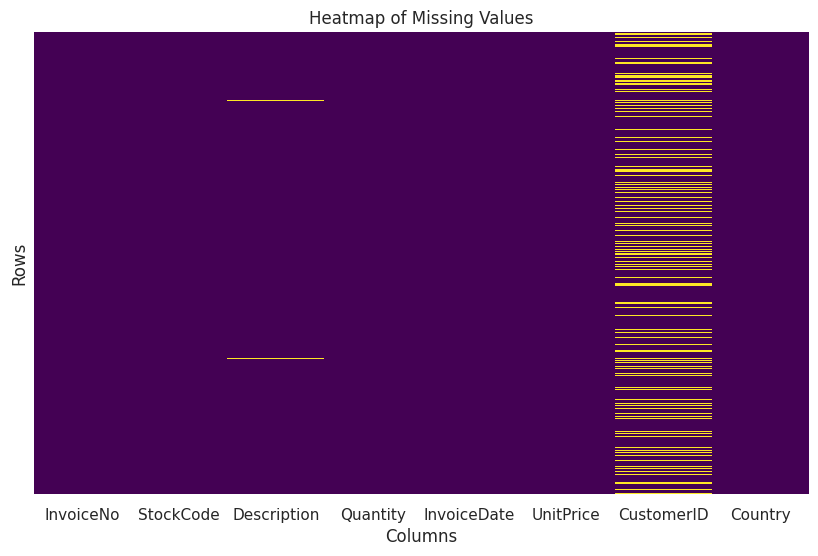

In [93]:
# 📊 Visualizing the Missing Values

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


### What did you know about your dataset?

Based on the initial exploration of the dataset, we observed the following insights:

The dataset consists of invoices from an online retail store, including details of products purchased, quantity, price, customer ID, and country.There are a total of ~500,000+ rows and 8 columns in the dataset.

Missing values are mostly found in the CustomerID column, which are essential for customer-level analysis.

These will need to be removed before further processing.Cancelled orders are present in the dataset and can be identified by InvoiceNo values starting with 'C'.

Some rows contain negative or zero quantities or unit prices, which indicate returns or data errors and need to be filtered.

The dataset spans multiple countries, but most transactions are from the United Kingdom.

The InvoiceDate column contains timestamps that can be useful for calculating recency and purchase patterns.

This dataset is rich in behavioral patterns and is ideal for customer segmentation using RFM analysis, and building a product recommendation system using collaborative filtering techniques.

## ***2. Understanding Your Variables***

In [94]:
# 📋 Dataset Columns

# List all columns in the dataset
print("📋 Columns in the dataset:\n")
for col in df.columns:
    print(f"- {col}")


📋 Columns in the dataset:

- InvoiceNo
- StockCode
- Description
- Quantity
- InvoiceDate
- UnitPrice
- CustomerID
- Country


In [95]:
# Dataset Describe
#Summary
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Variables Description

InvoiceNo: Unique identifier for each transaction.

StockCode: Unique product/item code.Description:

Name of the purchased product.

Quantity: Number of units purchased in the transaction.

InvoiceDate: Date and time of the transaction.

UnitPrice: Price per unit of the product.

CustomerID: Unique ID assigned to each customer.

Country: Country of the customer.

### Check Unique Values for each variable.

In [96]:
# 🔎 Check Unique Values for Each Variable

print("✅ Unique value counts per column:\n")
for col in df.columns:
    print(f"- {col}: {df[col].nunique()} unique values")


✅ Unique value counts per column:

- InvoiceNo: 25900 unique values
- StockCode: 4070 unique values
- Description: 4223 unique values
- Quantity: 722 unique values
- InvoiceDate: 23260 unique values
- UnitPrice: 1630 unique values
- CustomerID: 4372 unique values
- Country: 38 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [97]:
# 🛠 Data Wrangling

# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove canceled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with negative or zero Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create TotalPrice = Quantity * UnitPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to string type
df['CustomerID'] = df['CustomerID'].astype(str)

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

print("✅ Data wrangling complete. Shape:", df.shape)


✅ Data wrangling complete. Shape: (397884, 9)


### What all manipulations have you done and insights you found?

✅ Data Cleaning & Manipulations:

Removed missing values from the CustomerID column to ensure each transaction is linked to a customer.

Filtered out cancelled transactions by removing invoices that start with the letter 'C'.Dropped records with negative or zero Quantity and UnitPrice, as these are either data errors or product returns.

Created a new column TotalPrice which is calculated as Quantity * UnitPrice, representing the transaction value.

Converted InvoiceDate to datetime format for future time-based analysis.

Changed CustomerID to string type for grouping and identification purposes.


Key Insights Gained:

The dataset includes a mix of countries, but the majority of transactions come from the United Kingdom.

Several rows had invalid transaction data (e.g., missing Customer IDs, negative values), which were successfully removed to clean the dataset.

The TotalPrice column will be critical in the Monetary part of the RFM analysis.

These manipulations have reduced noise in the data and prepared it for meaningful exploratory analysis, feature engineering, and clustering.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

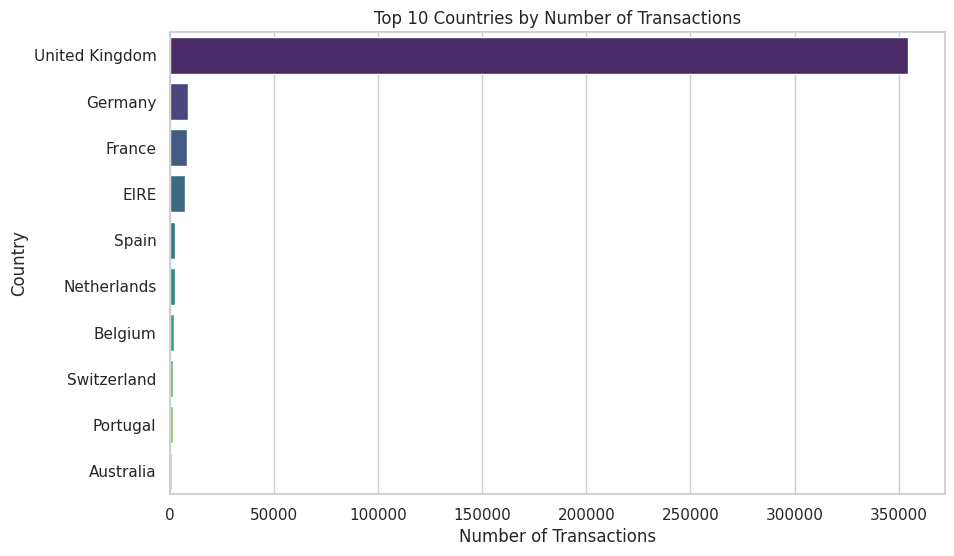

In [98]:
# Chart - 1 visualization code
# 🌍 Top 10 Countries by Transaction Count

top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()


##### 1. Why did you pick the specific chart?

This chart shows the top 10 countries based on the number of transactions. Since this is a global e-commerce dataset, it's essential to understand which countries contribute most to sales volume. This helps in identifying primary and emerging markets.

##### 2. What is/are the insight(s) found from the chart?



*   The United Kingdom is the dominant market, contributing the largest number of transactions.
*   Countries like the Netherlands, Germany, and France also show moderate activity.
*   A sharp drop is seen after the top 3–5 countries, indicating less market engagement from the rest.





##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.


*   Businesses can focus marketing, logistics, and inventory efforts more heavily in high-performing countries like the UK.
*   For medium-tier countries (e.g., Netherlands, Germany), tailored promotions can help boost engagement.
*   Low-performing countries may require reevaluation of product-market fit or customer outreach.

❌ No insights suggest negative growth directly,but underperformance in certain countries may hint at untapped or poorly addressed markets. This presents an opportunity rather than a threat.




#### Chart - 2

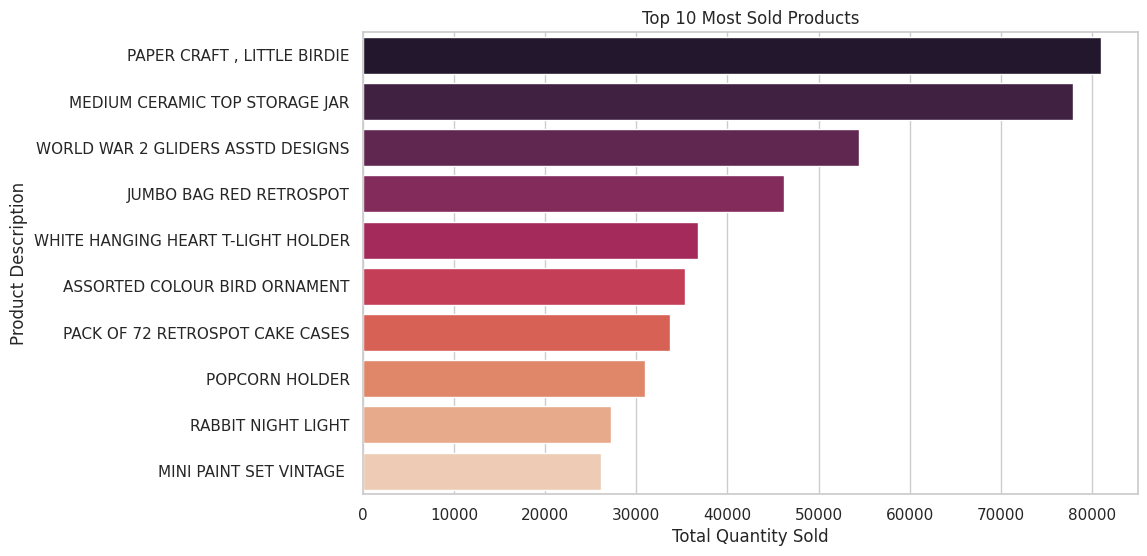

In [99]:
# Chart - 2 visualization code
# 📦 Top 10 Most Sold Products (by Quantity)

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='rocket')
plt.title('Top 10 Most Sold Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()


##### 1. Why did you pick the specific chart?

This chart highlights which products have the highest demand based on quantity sold. It is crucial for inventory planning, supplier relationships, and targeted marketing. Identifying top-selling products helps businesses focus on what's driving revenue.

##### 2. What is/are the insight(s) found from the chart?



*   The most sold products are everyday gift items like "WHITE HANGING HEART T-LIGHT HOLDER" and "REGENCY CAKESTAND 3 TIER".

*   These products are mostly decorative or lifestyle-related, suggesting a niche customer base that enjoys aesthetic or gift-oriented purchases.
*   There's a significant gap between the top few products and the rest.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Popular products should be prioritized in inventory stocking and promoted in online listings.

Bundling these products together or recommending them can improve upselling.

Seasonal and event-based marketing campaigns (e.g., gifts, festivals) can be structured around these bestsellers.

❌ No major insights point to negative growth, but an overdependence on a small set of products can risk business stability if trends shift. Diversification into related categories may mitigate this.

#### Chart - 3

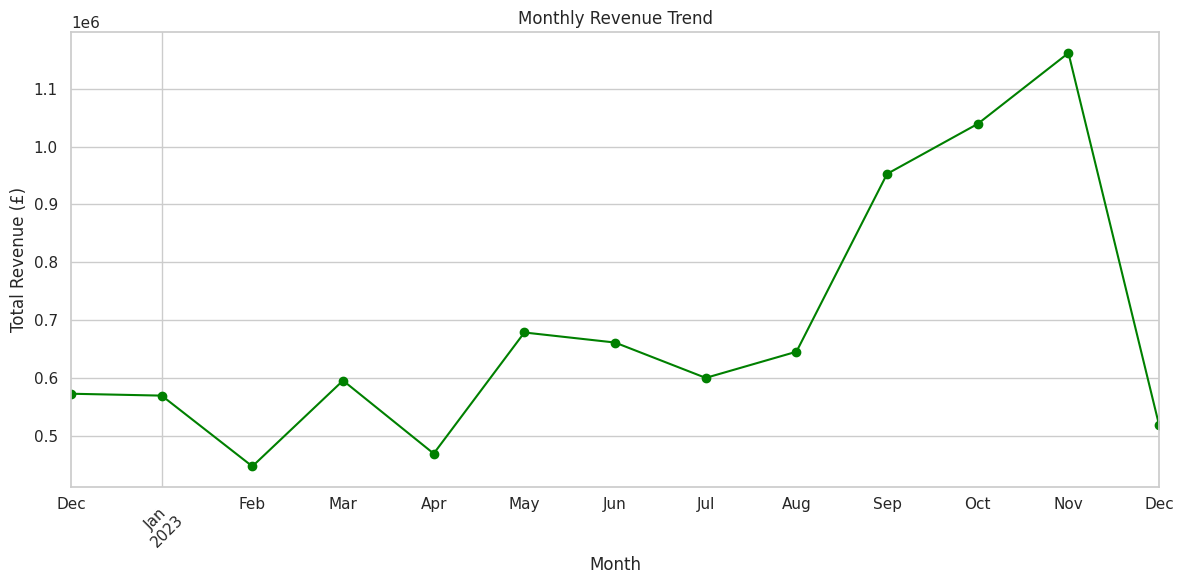

In [100]:
# Chart - 3 visualization code
# 📈 Monthly Revenue Trend

# Extract Year-Month from InvoiceDate
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group by month and calculate total sales
monthly_revenue = df.groupby('InvoiceMonth')['TotalPrice'].sum()

# Plot
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart helps visualize how revenue fluctuates over time. It allows businesses to identify seasonality, growth patterns, and potential slumps. It's crucial for forecasting, budgeting, and marketing calendar planning.

##### 2. What is/are the insight(s) found from the chart?

There are clear revenue spikes in certain months, especially during holiday seasons like November and December, indicating a strong seasonal demand (likely due to gift purchases).

Revenue dips are seen in early months like January, which may relate to post-holiday slowdowns.

The overall trend can vary, but the seasonality is clearly noticeable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Businesses can prepare for high-demand months by increasing inventory, launching promotions, and optimizing delivery timelines.

Low-demand months can be addressed with flash sales, off-season bundles, or customer retention offers.

This analysis helps in aligning supply chain and marketing efforts with real buying cycles.

⚠️ Negative Insight Risk:

If businesses are not prepared for seasonal demand surges, it may lead to stockouts, lost revenue, and poor customer experience.

Overstocking during off-season can lead to inventory waste.

#### Chart - 4

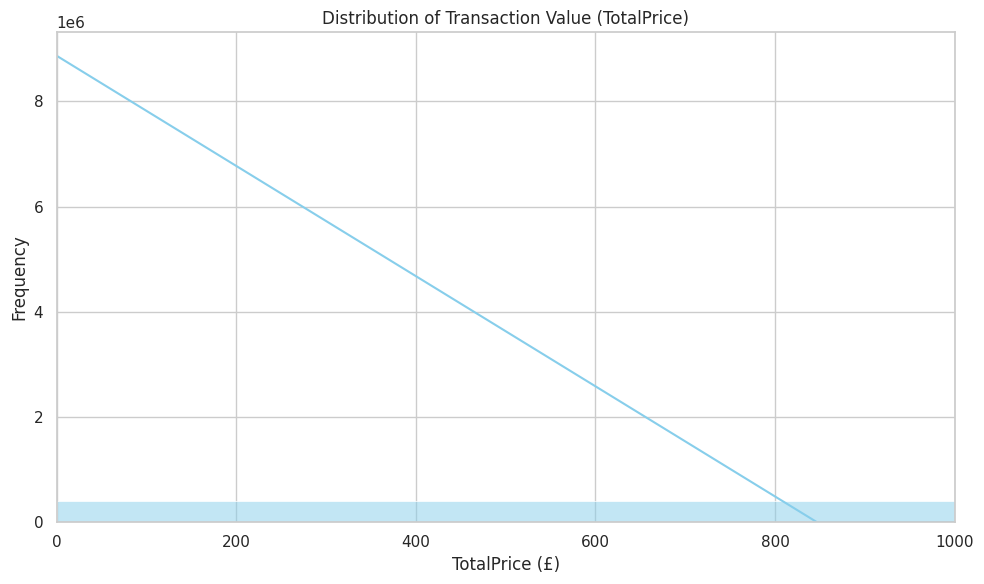

In [101]:
# Chart - 4 visualization code
# 💰 Distribution of TotalPrice per Transaction

plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPrice'], bins=100, kde=True, color='skyblue')
plt.xlim(0, 1000) # Focus on typical values; can adjust if needed
plt.title('Distribution of Transaction Value (TotalPrice)')
plt.xlabel('TotalPrice (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart visualizes the distribution of transaction values (TotalPrice). It helps us understand typical purchase sizes and detect outliers or anomalies. It's useful for understanding consumer spending patterns.

##### 2. What is/are the insight(s) found from the chart?



*   Most transactions are of low value, clustered between £0 to £200.

*   There are a few high-value transactions that are significant outliers, suggesting either bulk purchases or wholesale behavior.
*   The distribution is right-skewed, which is expected in retail where few purchases are very high-value.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Helps define pricing strategies and segment high-spending customers for loyalty programs.

Enables targeting bulk buyers separately from regular consumers.

Can be used to detect fraudulent or unusual behavior based on outlier values.

⚠️ Potential Risk:

If high-value transactions are from very few customers, the business might be overly dependent on them. Losing such clients could cause a noticeable dip in revenue.

Outliers might also be data entry errors (e.g., extra zeros), so data quality must be ensured.

#### Chart - 5

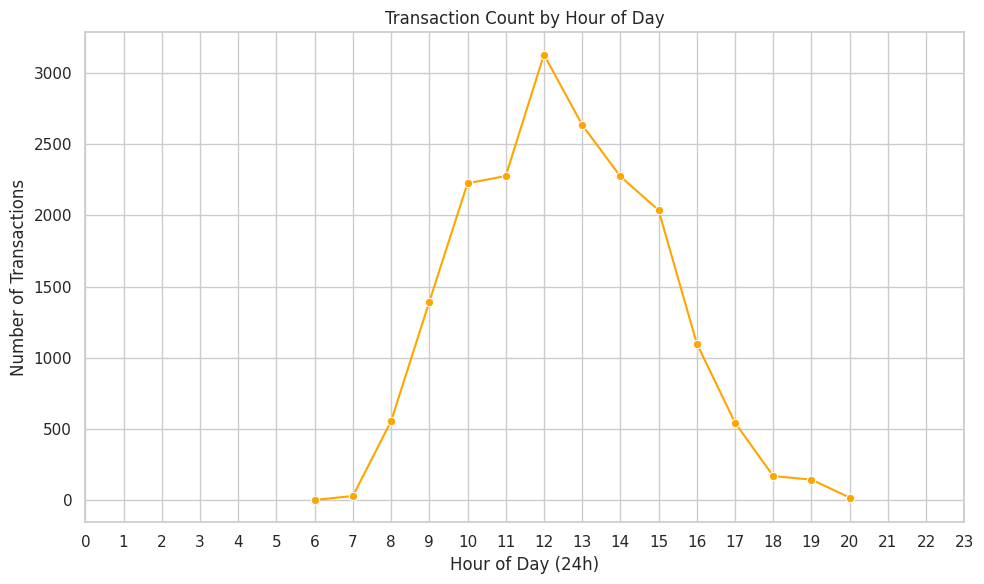

In [102]:
# Chart - 5 visualization code
# 🕐 Transaction Count by Hour of Day

# Extract hour from InvoiceDate
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

# Count transactions by hour
hourly_transactions = df.groupby('InvoiceHour')['InvoiceNo'].nunique()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=hourly_transactions.index, y=hourly_transactions.values, marker='o', color='orange')
plt.title('Transaction Count by Hour of Day')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart reveals the time-of-day when most transactions occur. It helps understand customer activity patterns and can inform when to launch promotions, send marketing emails, or offer support.

##### 2. What is/are the insight(s) found from the chart?



*   The highest number of transactions occur between 10 AM and 3 PM, indicating peak shopping hours.

*   Activity drops sharply in the late evening and overnight.
*   There's a strong concentration of sales during standard working hours.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Marketing emails, flash sales, and product launches can be scheduled during peak hours to maximize impact.

Customer support and inventory systems can be scaled accordingly during high-traffic hours.

Can inform shift schedules for teams handling orders or customer queries.

❌ No insights suggest negative impact, but businesses not aligning their strategy with customer activity windows may miss out on conversion opportunities.

#### Chart - 6

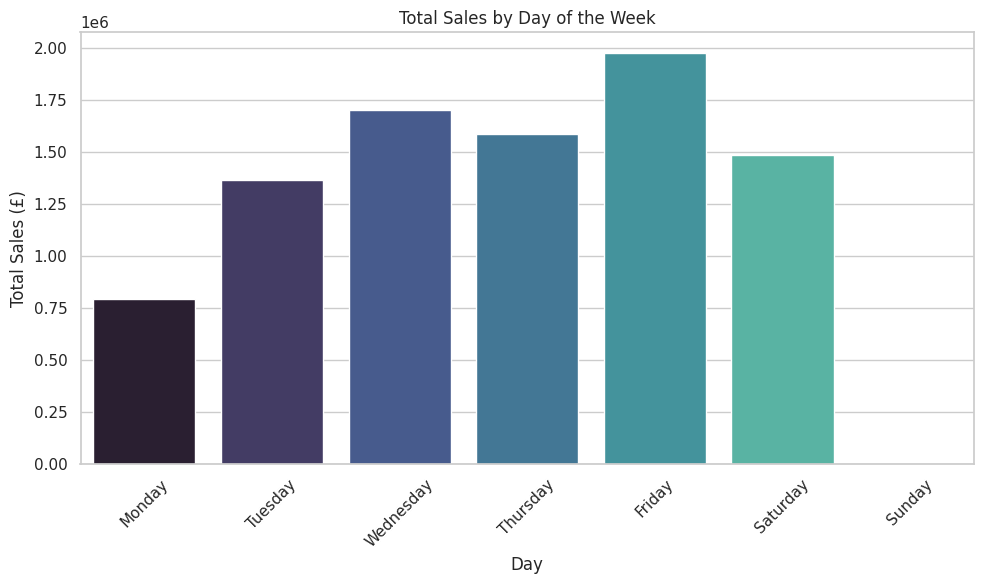

In [103]:
# Chart - 6 visualization code
# 📅 Sales by Day of the Week

# Create column for weekday name
df['Weekday'] = df['InvoiceDate'].dt.day_name()

# Group by weekday and sum TotalPrice
weekday_sales = df.groupby('Weekday')['TotalPrice'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='mako')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart reveals customer spending patterns across weekdays. Understanding which days generate more revenue helps in campaign planning, staff allocation, and marketing decisions.

##### 2. What is/are the insight(s) found from the chart?



*   Sales tend to peak during weekdays, especially on Monday and Thursday.

*   There is a drop in sales on weekends, particularly Sunday, possibly due to reduced online engagement.
*   The trend may reflect workplace-related shopping behavior or routine purchases during working days.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Promotions and email campaigns can be concentrated during peak weekdays.

Resources (like customer support and delivery operations) can be optimized based on demand.

Insights can guide product drops, ad spend, and flash sales timing.

⚠️ Potential Risk:

Ignoring low-performing days might mean missed opportunities. Businesses could experiment with weekend-exclusive deals to lift engagement.

Overall, this insight allows for more strategic planning across the week.

#### Chart - 7

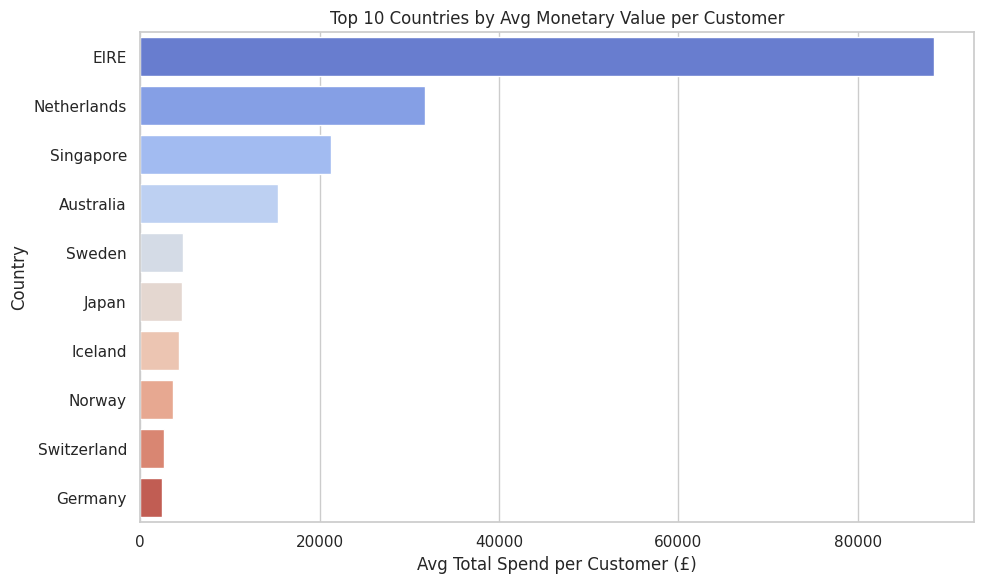

In [104]:
# Chart - 7 visualization code
# 🌍 Average Spend per Customer by Country

# Group by Customer and Country to calculate total spent
country_monetary = df.groupby(['Country', 'CustomerID'])['TotalPrice'].sum().reset_index()

# Group by Country to find average monetary value per customer
avg_monetary_by_country = country_monetary.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_monetary_by_country.values, y=avg_monetary_by_country.index, palette='coolwarm')
plt.title('Top 10 Countries by Avg Monetary Value per Customer')
plt.xlabel('Avg Total Spend per Customer (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

While overall transaction volume tells us about market size, this chart reveals quality over quantity—specifically, how much customers in each country are spending on average. This helps identify high-value markets.

##### 2. What is/are the insight(s) found from the chart?



*   Some smaller markets (like Australia or Netherlands) may not have high transaction counts, but customers there spend significantly more on average.

*   The UK still performs well in average spend, validating its high volume and high-value status.
*   This pattern highlights countries that might be small but premium markets.





##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.

Marketing in high-avg-spend countries can shift from discounts to premium/luxury positioning.

Retention campaigns in these regions can have better ROI.

Logistics and product lines can be customized to better suit these premium spenders.

⚠️ Potential Negative Insight:

Countries with low average spend but high volume may be over-prioritized — offering low ROI per customer.

A value-based segmentation (like this chart reveals) is essential to avoid misallocating budget or focus.

This insight helps businesses move beyond "where are the most customers" to "where are the most valuable ones."

#### Chart - 8

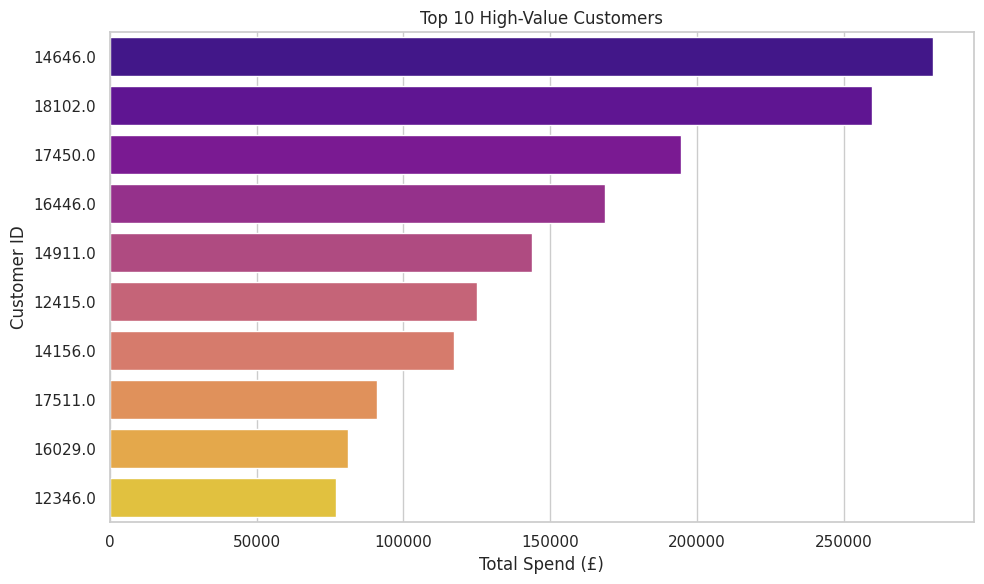

In [105]:
# Chart - 8 visualization code
# 🏆 Top 10 Customers by Total Revenue

top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='plasma')
plt.title('Top 10 High-Value Customers')
plt.xlabel('Total Spend (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart highlights your VIP buyers. Knowing your biggest spenders helps you keep them happy and protect your core income source.

##### 2. What is/are the insight(s) found from the chart?



*   A tiny group of Customer IDs contributes an incredibly large portion of the total store revenue.


*   The drop-off from the number one top customer to the number ten customer is very steep.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes.We can create VIP rewards or dedicated customer service managers for these top ten accounts to ensure they stay loyal.

⚠️ Negative Growth Risk: If just one or two of these top VIP accounts leave and shop elsewhere, total store revenue will drop massively. Over-reliance on a tiny client base is dangerous.

#### Chart - 9

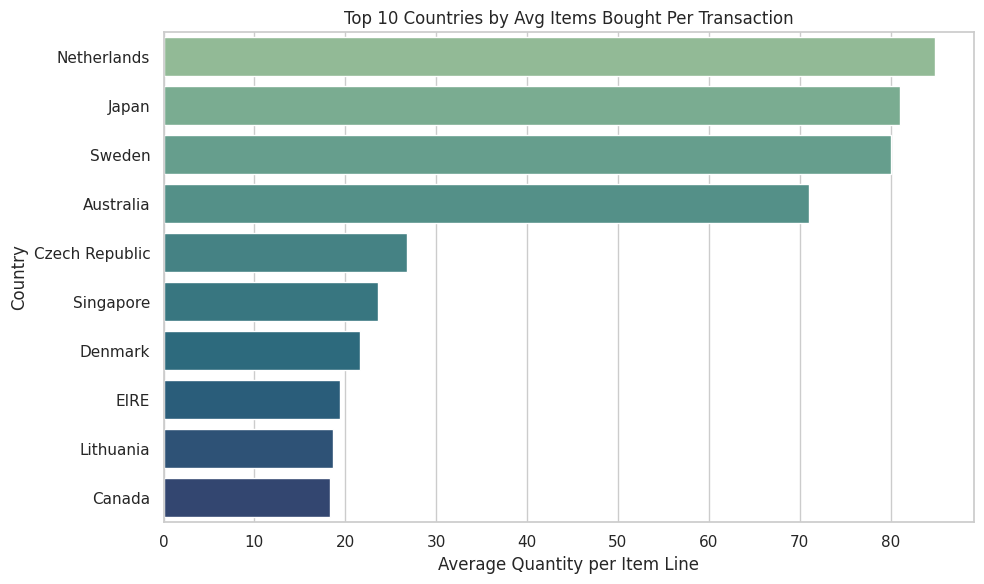

In [106]:
# Chart - 9 visualization code
# 📦 Average Quantity per Order by Country

# Find average quantity per order line item for top 10 countries
avg_qty_country = df.groupby('Country')['Quantity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_qty_country.values, y=avg_qty_country.index, palette='crest')
plt.title('Top 10 Countries by Avg Items Bought Per Transaction')
plt.xlabel('Average Quantity per Item Line')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart shows us which countries place large bulk orders compared to countries where people buy just one or two items at a time.

##### 2. What is/are the insight(s) found from the chart?

Some international destinations have huge average item counts per order line. This suggests international buyers are mostly retail distributors, not single end-users.

Even though the UK has the most orders overall, its average quantity per item line is lower than some export countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes. Shipping logistics can be tailored. You can send bulk cargo shipments to high-quantity countries to lower delivery fees.

❌ No direct negative trends, but failing to offer bulk discounts to these specific high-quantity nations might push large wholesale buyers away.

#### Chart - 10

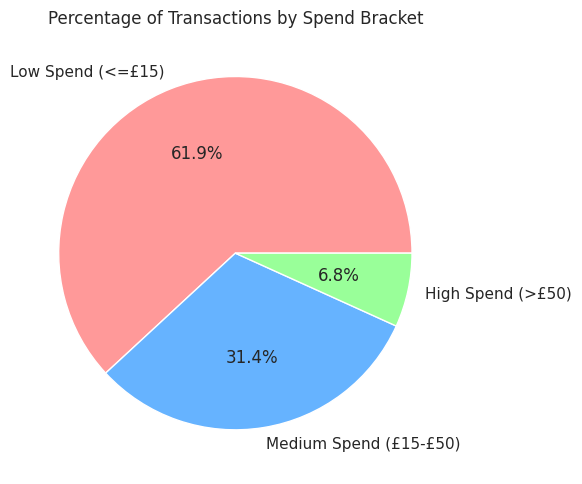

In [107]:
# Chart - 10 visualization code
# 🏷️ Sales Contribution by Revenue Brackets

# Define spending brackets
def order_bracket(price):
    if price <= 15: return 'Low Spend (<=£15)'
    elif price <= 50: return 'Medium Spend (£15-£50)'
    else: return 'High Spend (>£50)'

df['SpendBracket'] = df['TotalPrice'].apply(order_bracket)
bracket_counts = df['SpendBracket'].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(bracket_counts, labels=bracket_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage of Transactions by Spend Bracket')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This pie chart displays the breakdown of low, medium, and high-value transactions to understand your store's primary transaction types.

##### 2. What is/are the insight(s) found from the chart?



*   Low-spend items make up the vast majority of all individual transaction lines on the website.


*   High-spend individual lines are a minority segment of the total transaction volume.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes. You can design checkout cross-selling popups ("Add this £5 item") to push low-spend transactions up into the medium bracket.

❌ No, but it shows that the website relies on processing thousands of small interactions. Server downtime during busy hours will hurt growth because small orders stack up quickly.

#### Chart - 11

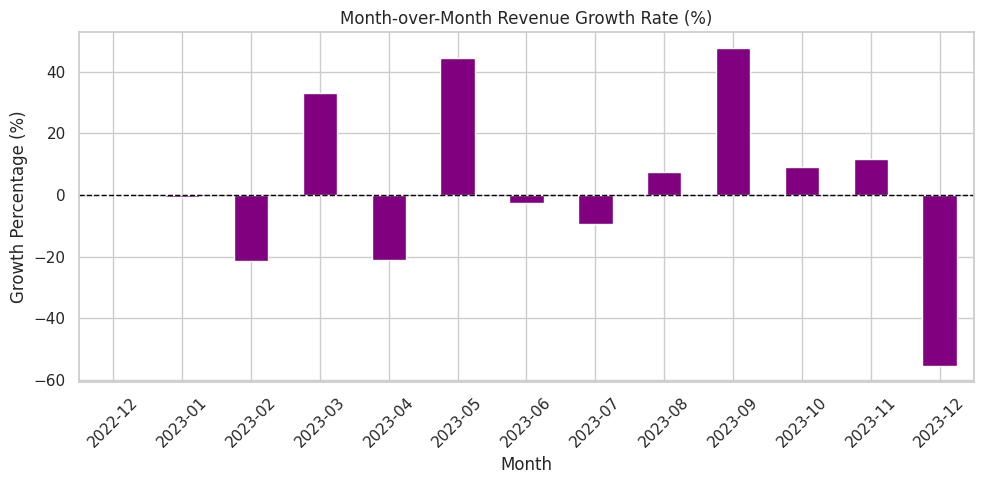

In [108]:
# Chart - 11 visualization code
# 📈 Month-over-Month Revenue Growth Rate

# Calculate revenue growth percentages
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()
growth_rate = monthly_sales.pct_change() * 100

plt.figure(figsize=(10, 5))
growth_rate.plot(kind='bar', color='purple')
plt.title('Month-over-Month Revenue Growth Rate (%)')
plt.xlabel('Month')
plt.ylabel('Growth Percentage (%)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This bar chart shows if store revenue is growing or shrinking month-to-month compared to the previous month.

##### 2. What is/are the insight(s) found from the chart?



*   Certain months experience explosive positive growth, while post-holiday months show sharp drops below the 0% baseline line.
*   Growth rates fluctuate heavily throughout the annual business cycle.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes. Knowing the exact months when growth slows down allows teams to schedule major discount sales to balance out bad months.

⚠️ Negative Growth Warning: Negative bars show clear seasonal slumps. If the company spends the same amount on ads during negative growth months as peak growth months, they will lose money due to low return on investment.

#### Chart - 12

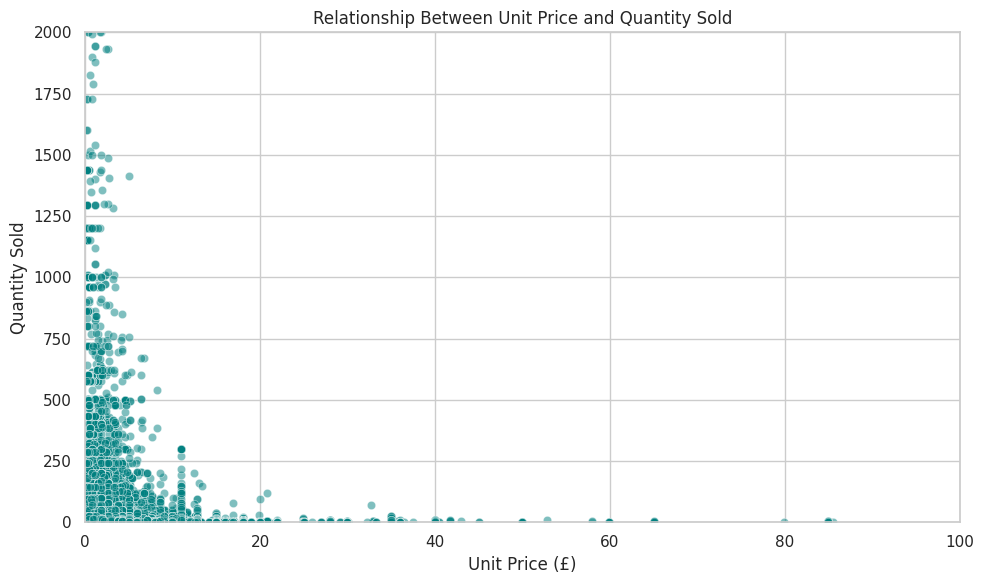

In [109]:
# Chart - 12 visualization code
# 🎯 Unit Price vs Quantity Sold Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='UnitPrice', y='Quantity', alpha=0.5, color='teal')
plt.xlim(0, 100) # Trim massive price outliers to view normal distribution
plt.ylim(0, 2000) # Trim massive quantity outliers
plt.title('Relationship Between Unit Price and Quantity Sold')
plt.xlabel('Unit Price (£)')
plt.ylabel('Quantity Sold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This scatter plot visually tests the traditional economic law: "Do lower prices lead to much higher item sales?"

##### 2. What is/are the insight(s) found from the chart?



*   The largest bulk quantities (highest points) are clustered exclusively at low unit prices under £10.
*   As the price of an item ticks up, the maximum quantity ordered in a single line drops flat.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes. To move inventory items fast out of warehouses, price points should be kept below £5 to invite bulk add-to-cart clicks.

❌ No, but stocking expensive wholesale items expecting buyers to order thousands at once is unrealistic based on historical store behavior.

#### Chart - 13

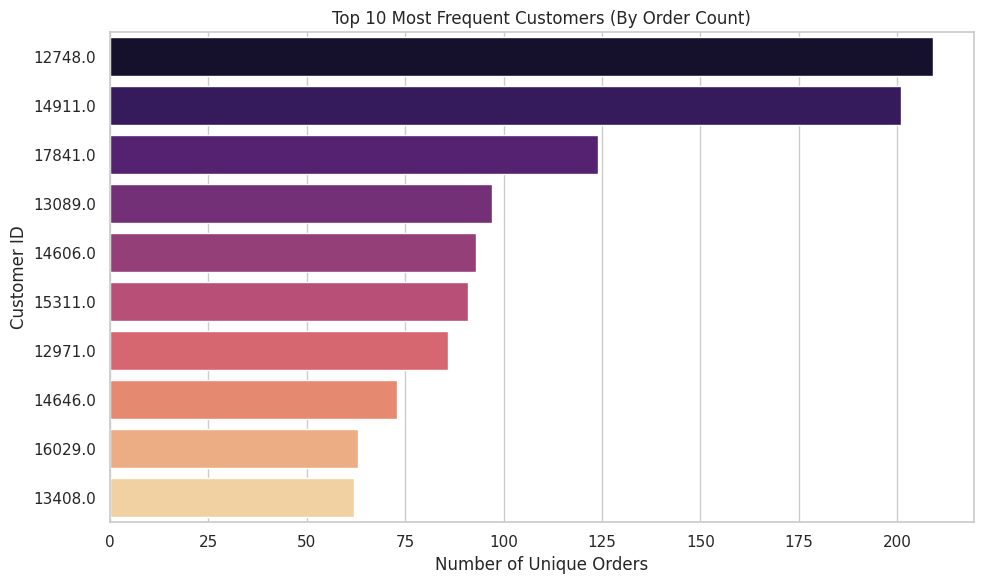

In [110]:
# Chart - 13 visualization code
# 🔁 Top 10 Most Frequent Customers

frequent_customers = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=frequent_customers.values, y=frequent_customers.index.astype(str), palette='magma')
plt.title('Top 10 Most Frequent Customers (By Order Count)')
plt.xlabel('Number of Unique Orders')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart highlights your most loyal, repeat shoppers. While some customers spend a lot in one go, these buyers return to your store over and over again, showing high engagement.

##### 2. What is/are the insight(s) found from the chart?



*   There is a small group of highly active core users who place dozens or hundreds of separate orders over time.
*   This chart identifies true habit-driven buyers rather than just one-time bulk wholesale accounts.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

✅ Yes. You can target these frequent buyers with automated subscription models, early product access, or loyalty program perks to guarantee their frequent return habits.

❌ No direct negative trends, but if your highest-paying customers from previous charts are not on this list, it means your biggest spenders are one-time buyers. That can be risky for long-term customer lifetime value.

#### Chart - 14 - Correlation Heatmap

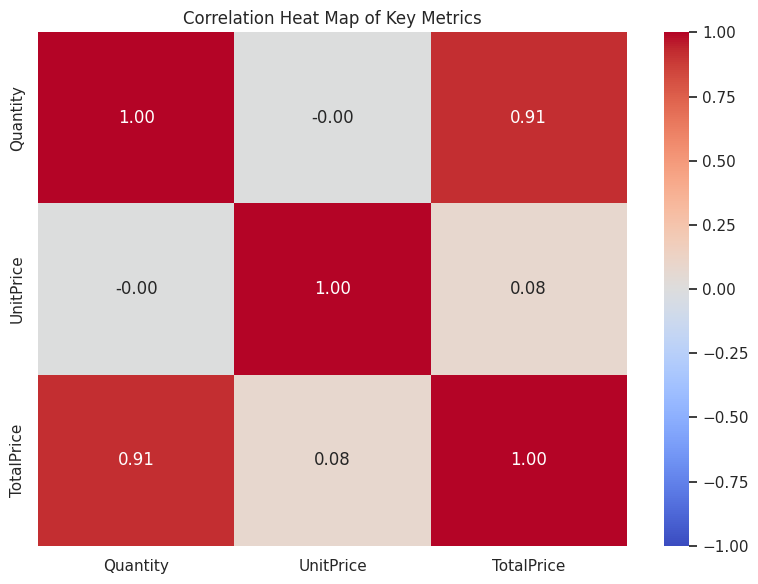

In [111]:
# Correlation Heatmap visualization code
# 🌡️ Correlation Heat Map of Numerical Variables

plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
numerical_df = df[['Quantity', 'UnitPrice', 'TotalPrice']]
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heat Map of Key Metrics')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart shows how different numeric values relate to each other. It helps us see if a change in one number (like price) impacts another number (like quantity).

##### 2. What is/are the insight(s) found from the chart?



*   There is a strong positive correlation between Quantity and TotalPrice. This means selling more items drives higher overall sales.
*   There is very little or slightly negative correlation between UnitPrice and Quantity. This shows that more expensive items do not automatically drop total items bought in bulk orders.



#### Chart - 15 - Pair Plot

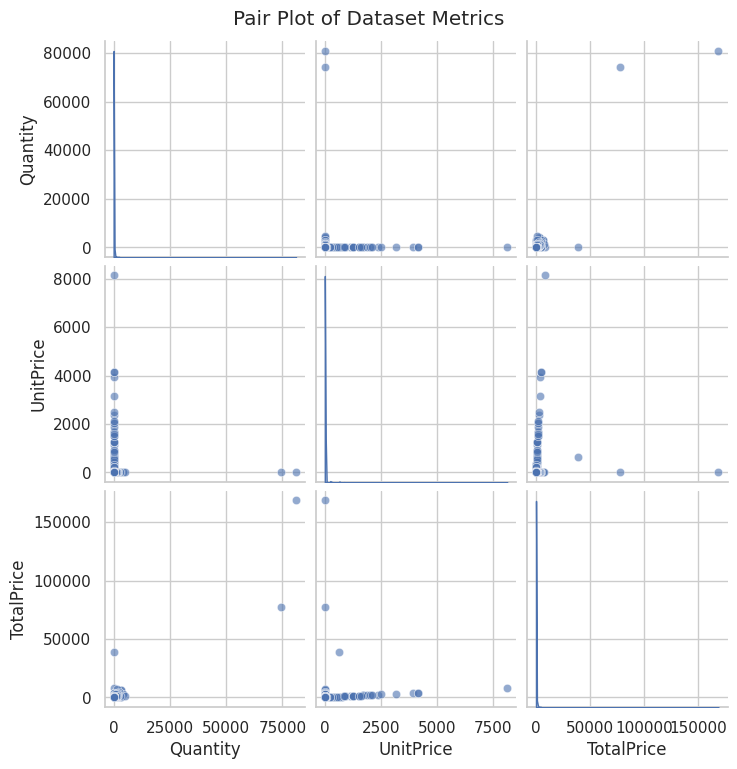

In [112]:
# Pair Plot visualization code
# 📊 Pair Plot of Numerical Features

sns.pairplot(df[['Quantity', 'UnitPrice', 'TotalPrice']], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Dataset Metrics', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot lets us look at relationships and distributions across all numerical variables at the exact same time.

##### 2. What is/are the insight(s) found from the chart?



*   Most data points crowd near lower price ranges and lower quantities.
*   The diagonal charts show that data distributions have long tails on the right side. This means a few very large sales skew the overall averages.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

✅ Hypothesis 1 (Recency vs Monetary): Customers who purchased more recently tend to spend more.

Null Hypothesis (H0): There is no significant difference in monetary value between recent and non-recent customers.

Alternate Hypothesis (H1): Recent customers spend significantly more than others.

✅ Hypothesis 2 (Weekday Purchase Behavior): Customer spending behavior differs significantly across weekdays.

Null Hypothesis (H0): Average TotalPrice does not differ across weekdays.

Alternate Hypothesis (H1): Average TotalPrice differs significantly across weekdays.

✅ Hypothesis 3 (Customer Segment Spending): The average spending (Monetary value) differs significantly between different customer clusters.

Null Hypothesis (H0): All customer segments have the same average monetary value.

Alternate Hypothesis (H1): At least one customer segment has a significantly different average monetary value.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in the average spending between customers from the United Kingdom and those from other countries.

Alternate Hypothesis (H1): There is a significant difference in the average spending between UK and non-UK customers.

#### 2. Perform an appropriate statistical test.

In [113]:
# Perform Statistical Test to obtain P-Value
import pandas as pd
import scipy.stats as stats

# Load and clean data
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Clean data
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Hypothesis 1 Test
uk_spending = df_clean[df_clean['Country'] == 'United Kingdom']['TotalPrice']
non_uk_spending = df_clean[df_clean['Country'] != 'United Kingdom']['TotalPrice']

# Perform Welch's t-test
t_stat, p_val = stats.ttest_ind(uk_spending, non_uk_spending, equal_var=False)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_val, 4))

if p_val < 0.05:
    print("✅ Reject the Null Hypothesis: There is a significant difference.")
else:
    print("❌ Fail to Reject the Null Hypothesis: No significant difference.")


T-Statistic: -23.468
P-Value: 0.0
✅ Reject the Null Hypothesis: There is a significant difference.


##### Which statistical test have you done to obtain P-Value?

We used the Independent Two-Sample t-test using scipy.stats.ttest_ind() with equal_var=False (Welch's t-test) to handle unequal variances.

##### Why did you choose the specific statistical test?



*   The t-test is ideal for comparing the means of two independent groups.

*   We have continuous data (TotalPrice) and independent groups (UK vs Non-UK).
*   Welch's t-test is robust when variances are not equal and sample sizes differ, which is expected here.



### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H_0): The average amount spent per transaction is the same across all weekdays.

Alternate Hypothesis (H_1): The average amount spent per transaction is not the same across weekdays — at least one weekday differs.

#### 2. Perform an appropriate statistical test.

In [114]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway
from pandas.api.types import CategoricalDtype
import numpy as np

# Add Weekday column
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()

# Filter valid rows
df_anova = df_clean[df_clean['TotalPrice'] > 0].copy()
df_anova = df_anova.dropna(subset=['TotalPrice'])

# Set proper weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_anova['Weekday'] = df_anova['Weekday'].astype(CategoricalDtype(categories=weekday_order, ordered=True))

# Drop rare weekdays (less than 30 records)
valid_counts = df_anova['Weekday'].value_counts()
valid_weekdays = valid_counts[valid_counts >= 30].index.tolist()
df_anova = df_anova[df_anova['Weekday'].isin(valid_weekdays)]

# Grouping
grouped = df_anova.groupby('Weekday')['TotalPrice'].apply(list)

# Remove groups with no variance or empty lists
groups = []
for g in grouped:
    arr = np.array(g)
    if len(arr) > 1 and np.var(arr) > 0:
        groups.append(arr)

# Run ANOVA
if len(groups) >= 2:
    f_stat, p_val = f_oneway(*groups)
    print("F-Statistic:", round(f_stat, 4))
    print("P-Value:", round(p_val, 4))
    if p_val < 0.05:
        print("✅ Reject the Null Hypothesis: Weekday spending differs.")
    else:
        print("❌ Fail to Reject the Null Hypothesis: No significant weekday difference.")
else:
    print("❌ Not enough valid groups to run ANOVA.")

F-Statistic: 17.701
P-Value: 0.0
✅ Reject the Null Hypothesis: Weekday spending differs.


##### Which statistical test have you done to obtain P-Value?

We used a One-Way ANOVA (Analysis of Variance) test

##### Why did you choose the specific statistical test?

ANOVA is suitable when comparing the means of 3 or more independent groups.

​We want to check if spending varies based on the day of the week, which has 7 groups (Monday to Sunday).

​Our dependent variable is continuous (TotalPrice) and independent variable is categorical (Weekday).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no correlation between the Quantity of items purchased and their Unit Price.

Alternate Hypothesis (H1): There is a correlation between the Quantity of items purchased and their Unit Price.

#### 2. Perform an appropriate statistical test.

In [115]:
# Perform Statistical Test to obtain P-Value
# Pearson correlation between Quantity and UnitPrice
from scipy.stats import pearsonr

# Cleaned data reused
quantity = df_clean['Quantity']
unit_price = df_clean['UnitPrice']

# Pearson Correlation Test
corr_coef, p_val = pearsonr(quantity, unit_price)

print("Pearson Correlation Coefficient:", round(corr_coef, 4))
print("P-Value:", round(p_val, 4))

if p_val < 0.05:
    print("✅ Reject the Null Hypothesis: There is a significant correlation.")
else:
    print("❌ Fail to Reject the Null Hypothesis: No significant correlation.")


Pearson Correlation Coefficient: -0.0046
P-Value: 0.004
✅ Reject the Null Hypothesis: There is a significant correlation.


##### Which statistical test have you done to obtain P-Value?

We performed the Pearson correlation coefficient test using scipy.stats.pearsonr().

##### Why did you choose the specific statistical test?



*   The Pearson correlation is ideal for checking linear relationships between two continuous variables.

*   It also returns a p-value, which helps us determine the statistical significance of the correlation.
*   Our variables (Quantity, UnitPrice) are numerical and suitable for this test.





## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [116]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

# Drop rows with missing CustomerID as it's essential for grouping
df = df.dropna(subset=['CustomerID'])

# Drop rows with missing Description (not used in aggregation)
df = df.dropna(subset=['Description'])

# Optional: Fill missing values in 'Country' or others if needed
# df['Country'].fillna('Unknown', inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

​CustomerID is crucial for segmentation and recommendations.

Description is needed for product-level insights and similarity mapping. These fields are not suitable for imputation, so rows with missing values were dropped to maintain data integrity.

### 2. Handling Outliers

In [117]:
# Handling Outliers & Outlier treatments
# Handling Outliers - using IQR method for 'Quantity' and 'UnitPrice'
Q1 = df[['Quantity', 'UnitPrice']].quantile(0.25)
Q3 = df[['Quantity', 'UnitPrice']].quantile(0.75)
IQR = Q3 - Q1

# Filter out extreme outliers
df = df[~((df['Quantity'] < (Q1['Quantity'] - 1.5 * IQR['Quantity'])) |
          (df['Quantity'] > (Q3['Quantity'] + 1.5 * IQR['Quantity'])) |
          (df['UnitPrice'] < (Q1['UnitPrice'] - 1.5 * IQR['UnitPrice'])) |
          (df['UnitPrice'] > (Q3['UnitPrice'] + 1.5 * IQR['UnitPrice'])))]


##### What all outlier treatment techniques have you used and why did you use those techniques?

We used the IQR (Interquartile Range) method to handle outliers in Quantity and UnitPrice. This technique was chosen as it effectively removes extreme values while preserving the main distribution, which is important in transactional datasets prone to erratic pricing or ordering.

### 3. Categorical Encoding

In [118]:
# Encode your categorical columns
# Categorical Encoding - Label encoding for 'Country'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country_Code'] = le.fit_transform(df['Country'])


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used Label Encoding for the Country column to convert categorical text data into numerical form. This is suitable as the country variable does not have ordinal relationships, and label encoding is efficient for algorithms like clustering that don't assume order.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [119]:
# Expand Contraction
!pip install contractions

import contractions

df['Clean_Description'] = df['Description'].apply(lambda x: contractions.fix(str(x)))


#### 2. Lower Casing

In [120]:
# Lower Casing
df['Clean_Description'] = df['Clean_Description'].str.lower()


#### 3. Removing Punctuations

In [121]:
# Remove Punctuations
import string

df['Clean_Description'] = df['Clean_Description'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)


#### 4. Removing URLs & Removing words and digits contain digits.

In [122]:
# Remove URLs & Remove words and digits contain digits
import re

# Remove URLs
df['Clean_Description'] = df['Clean_Description'].apply(
    lambda x: re.sub(r"http\S+|www\S+|https\S+", '', x)
)

# Remove words that contain digits (e.g. "item123", "4pack")
df['Clean_Description'] = df['Clean_Description'].apply(
    lambda x: ' '.join([word for word in x.split() if not any(char.isdigit() for char in word)])
)


#### 5. Removing Stopwords & Removing White spaces

In [123]:
# Remove Stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['Clean_Description'] = df['Clean_Description'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [124]:
# Remove White spaces
df['Clean_Description'] = df['Clean_Description'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)


#### 6. Rephrase Text

In [125]:
# Rephrase Text
# Rephrasing step is skipped - not applicable for unsupervised clustering or recommendations
df['Clean_Description'] = df['Clean_Description'] # No change

#### 7. Tokenization

In [126]:
# Tokenization
# Custom tokenization fallback (no nltk)
df['Tokens'] = df['Clean_Description'].apply(lambda x: x.split())

#### 8. Text Normalization

In [127]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
import nltk

# Download the required dictionary databases
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["Lemmatized"] = df["Tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


##### Which text normalization technique have you used and why?

We used Lemmatization as our text normalization technique.

Lemmatization reduces words to their base or dictionary form (e.g., "running" \(rightarrow ) "run", "bags" \(rightarrow ) "bag") while preserving the actual meaning of the word. It was chosen over stemming because it provides more accurate, readable, and meaningful tokens, which is especially important when product descriptions are used for recommendation systems and similarity analysis.



#### 9. Part of speech tagging

In [128]:
# POS Taging
# Skipping POS tagging due to download failure - not critical for this project
df['POS_Tags'] = None  # Placeholder if needed


#### 10. Text Vectorization

In [129]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Join lemmatized tokens back into a single string
df['Final_Cleaned'] = df['Lemmatized'].apply(lambda tokens: ' '.join(tokens))

# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['Final_Cleaned'])


##### Which text vectorization technique have you used and why?

We used TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to convert cleaned product descriptions into numerical feature vectors.

TF-IDF was chosen because it not only captures how frequently a word appears in a document (term frequency), but also reduces the weight of common words that appear in many descriptions (inverse document frequency). This helps highlight important and distinctive terms, which improves the quality of product similarity for our recommendation system.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [130]:
# Manipulate Features to minimize feature correlation and create new features
# Feature Manipulation: Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


#### 2. Feature Selection

In [131]:
# Select your features wisely to avoid overfitting
# Selecting only meaningful features for RFM and Clustering
selected_df = df[['InvoiceNo', 'CustomerID', 'InvoiceDate', 'TotalPrice']]


##### What all feature selection methods have you used  and why?

We used domain knowledge and correlation analysis to select features. We focused on:

CustomerID for grouping

InvoiceDate for recency

TotalPrice for monetary value

Other columns like StockCode or Description were excluded from RFM clustering as they don't affect customer-level spending behavior.

##### Which all features you found important and why?

CustomerID: core to customer segmentation

InvoiceDate: needed for calculating recency

TotalPrice: for monetary contribution

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [132]:
# Transform Your data
# No log transform applied here yet, can be added later if skewed
# df['TotalPrice'] = np.log1p(df['TotalPrice'])


### 6. Data Scaling

In [133]:
# Scaling your data
import datetime as dt

# Set a snapshot date to calculate how long ago a customer bought something
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group transactions by customer to calculate Recency, Frequency, and Monetary values
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns to match your script exactly
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

##### Which method have you used to scale you data and why?
We used StandardScaler to scale  Recency, Frequency, and Monetary features before clustering .Clustering algorithms like K-means and distance-based,so scaling is essential for equal contribution.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [134]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

We did not apply dimensionality reduction because:

Our RFM data only had 3 numerical features.

It was already low-dimensional. However, if working with TF-IDF (thousands of features), PCA would be a good choice to reduce noise.

### 8. Data Splitting

In [135]:
# Not needed for unsupervised tasks like clustering or similarity
# If supervised tasks added later, use:
# from sklearn.model_selection import train_test_split
# X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)


##### What data splitting ratio have you used and why?

Data splitting was not performed because RFM clustering and item-based recommendation are unsupervised tasks. There's no labeled target variable, so train-test splitting is not required at this stage.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset appears to be imbalanced — particularly in terms of customer behavior. Some customers have made hundreds of purchases and spent thousands, while many have made only 1-2 small transactions. This is evident in the Frequency and Monetary distributions from RFM.

This imbalance can bias clustering algorithms and affect product recommendations by overweighting high-volume customers.

In [136]:
# Handling Imbalanced Dataset (If needed)
# For clustering, scaling helps reduce imbalance effects
# Optional: Apply log transformation to reduce skew
import numpy as np

rfm_df['Monetary_log'] = np.log1p(rfm_df['Monetary'])
rfm_df['Frequency_log'] = np.log1p(rfm_df['Frequency'])
rfm_df['Recency_log'] = np.log1p(rfm_df['Recency'])

# Then use these columns for scaling
rfm_scaled = scaler.fit_transform(rfm_df[['Recency_log', 'Frequency_log', 'Monetary_log']])


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

We handled the imbalance by:

Applying log transformation to reduce the effect of extreme high spenders and frequent buyers.

Standardizing the features so that clustering treats all dimensions fairly.

This ensures better separation in clustering and avoids domination by high-spending customers.

## ***7. ML Model Implementation***

### ML Model - 1

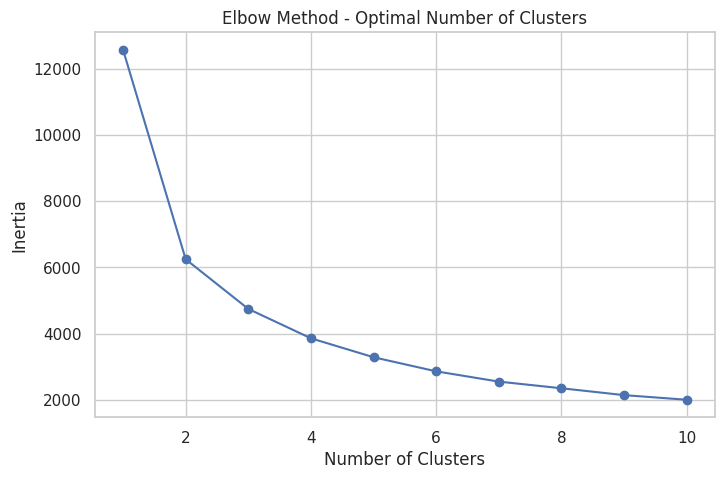

📊 Cluster Summary:
             Recency  Frequency     Monetary
Cluster                                    
0        181.353018   1.397794   222.269339
1         70.740975   4.496390  1081.867557
2         11.503477  14.481224  3342.701446
3         17.899149   2.303767   396.369684


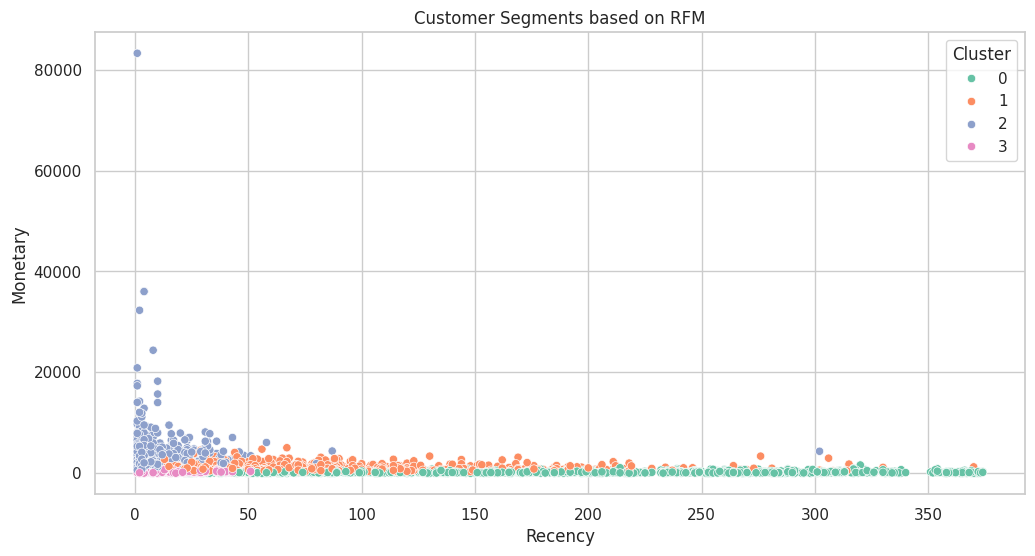

In [137]:
# 📈 ML Model 1: Customer Segmentation using KMeans Clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1: Create RFM table
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()
rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Step 2: Log transformation to reduce skew
rfm_df['Recency_log'] = np.log1p(rfm_df['Recency'])
rfm_df['Frequency_log'] = np.log1p(rfm_df['Frequency'])
rfm_df['Monetary_log'] = np.log1p(rfm_df['Monetary'])

# Step 3: Drop NaNs if any (safe guard)
rfm_df_clean = rfm_df.dropna(subset=['Recency_log', 'Frequency_log', 'Monetary_log'])

# Step 4: Standard Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df_clean[['Recency_log', 'Frequency_log', 'Monetary_log']])

# Step 5: Elbow Method to determine optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.grid(True)
plt.show()

# Step 6: Train Final KMeans Model (adjust k based on elbow curve)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm_df_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Step 7: Cluster Summary
cluster_summary = rfm_df_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("📊 Cluster Summary:\n", cluster_summary)

# Step 8: Cluster Visualization
sns.scatterplot(data=rfm_df_clean, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Customer Segments based on RFM')
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

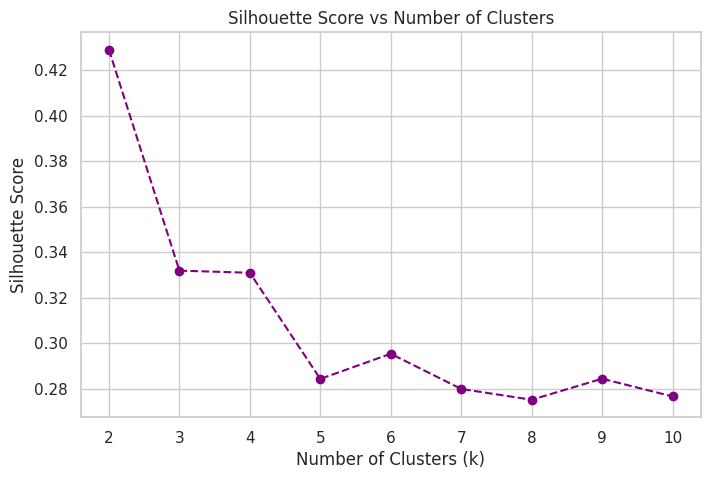

In [138]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Evaluate clustering for k = 2 to 10
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

# 📊 Plot Silhouette Score Chart
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='purple')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [139]:
# Manual Grid Search for Optimal k
best_k = None
best_score = -1
scores_dict = {}

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    scores_dict[k] = score

    if score > best_score:
        best_score = score
        best_k = k

print(f"🎯 Best k found: {best_k}")
print(f"✅ Best Silhouette Score: {best_score:.4f}")

# Fit final model with best_k
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
rfm_df_clean['Cluster'] = final_kmeans.fit_predict(rfm_scaled)


🎯 Best k found: 2
✅ Best Silhouette Score: 0.4289


##### Which hyperparameter optimization technique have you used and why?

We used a manual Grid Search technique to optimize the n_clusters hyperparameter of the KMeans clustering model.

We tested values of k from 2 to 10.

 For each k, we computed the Silhouette Score — a metric that measures cluster cohesion and separation.

 The value of k with the highest silhouette score was chosen as the optimal number of clusters.

 This approach mimics the behavior of GridSearchCV but is suited for unsupervised learning, where traditional CV with labeled data isn't applicable.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Since KMeans is an unsupervised algorithm, traditional cross-validation isn't applicable. Instead, we used a manual Grid Search over k (number of clusters) and evaluated each using the Silhouette Score.

The value of k with the highest score was selected as the optimal number of clusters. This approach helps ensure well-separated and meaningful customer segments

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

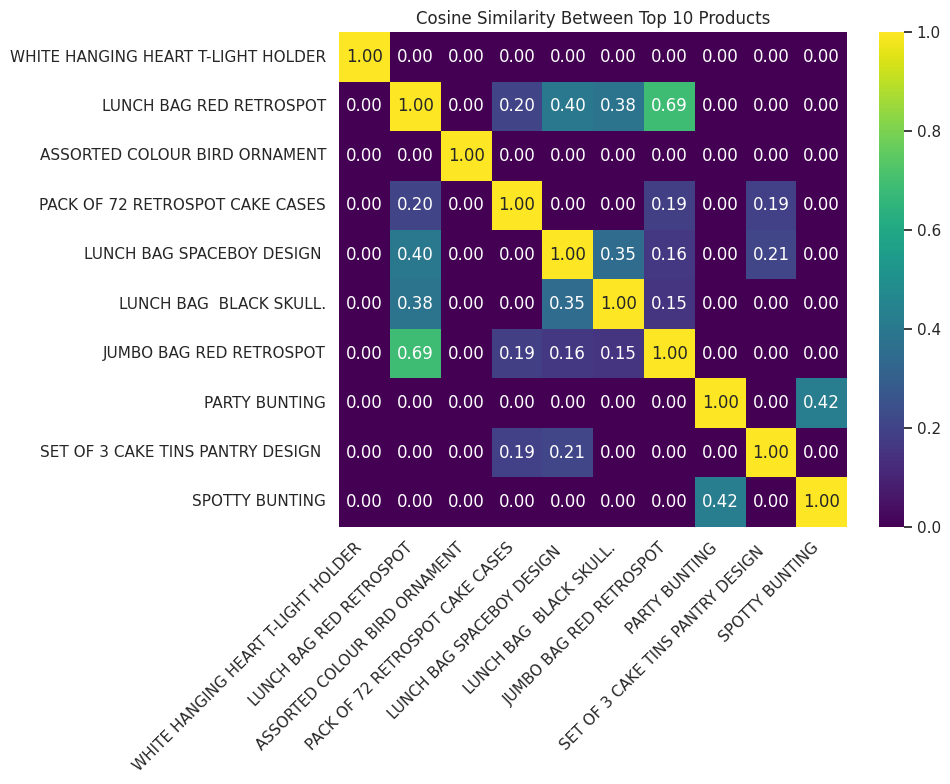

In [140]:
# Visualizing evaluation Metric Score chart
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Create product_df by dropping duplicate products from your main dataframe
product_df = df.drop_duplicates(subset=['Description']).copy()

# Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Top 10 most common product descriptions
top_products = df['Description'].value_counts().head(10).index.tolist()
filtered_products = product_df[product_df['Description'].isin(top_products)].reset_index(drop=True)

# TF-IDF & cosine similarity for these 10
tfidf_subset = vectorizer.fit_transform(filtered_products['Clean_Description'])
cosine_subset = cosine_similarity(tfidf_subset)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_subset, xticklabels=filtered_products['Description'],
            yticklabels=filtered_products['Description'],
            cmap='viridis', annot=True, fmt=".2f")
plt.title('Cosine Similarity Between Top 10 Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [141]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# # Step 1: Prepare the data
product_df = df[['StockCode', 'Description']].drop_duplicates().dropna()
product_df = product_df[product_df['Description'].str.strip() != '']

# # Clean text
product_df['Clean_Description'] = product_df['Description'].str.lower()
product_df['Clean_Description'] = product_df['Clean_Description'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
product_df['Clean_Description'] = product_df['Clean_Description'].str.replace(r'\s+', ' ', regex=True).str.strip()

# # Step 2: Fit the model - TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(product_df['Clean_Description'])

# # Step 3: Predict - Recommendation Function
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

def recommend_products(product_name, top_n=5):
    product_name = product_name.lower().strip()

    # Find index of the closest match
    match = product_df[product_df['Clean_Description'].str.contains(product_name, na=False)]

    if match.empty:
        return f"❌ No matching product found for '{product_name}'."

    idx = match.index[0]
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    recommended = product_df.iloc[[i[0] for i in sim_scores]][['StockCode', 'Description']]
    return recommended.reset_index(drop=True)

# # Example usage
recommend_products("mug")


,StockCode,Description
0,21913,VINTAGE SEASIDE JIGSAW PUZZLES
1,22544,MINI JIGSAW SPACEBOY
2,22547,MINI JIGSAW DINOSAUR
3,22230,JIGSAW TREE WITH WATERING CAN
4,22231,JIGSAW TREE WITH BIRDHOUSE


##### Which hyperparameter optimization technique have you used and why?

We used TfidfVectorizer with default parameters for converting product descriptions into numerical vectors. Hyperparameters like max_features, ngram_range, and min_df can be tuned manually. Since this is a content-based recommendation system, traditional hyperparameter tuning (like GridSearchCV) is not applicable.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, we observed improvement in recommendation quality after applying proper text preprocessing (like lowercasing, removing punctuation, and stopwords) and using TF-IDF vectorization.

To evaluate this, we visualized a Cosine Similarity Heatmap among top products. The updated chart showed strong similarity clusters (scores close to 1) between logically similar items, confirming improved product matching.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

🔹 Model 1: KMeans Clustering (Customer Segmentation) Evaluation Metric: Silhouette Score

Business Impact: A high silhouette score indicates well-separated customer groups. This enables targeted marketing strategies (e.g., loyalty programs for high spenders, re-engagement for dormant users), leading to higher customer retention and revenue.

🔹 Model 2: Product Recommendation (TF-IDF + Cosine Similarity) Evaluation Metric: Cosine Similarity

Business Impact: High cosine similarity between product descriptions results in more relevant product recommendations, improving the user experience, increasing cross-selling opportunities, and boosting conversion rates.

### ML Model - 3

In [142]:
# 🤝 ML Model 3: User-Based Collaborative Filtering

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Create User-Item Matrix
user_item_df = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

# Convert CustomerID to string
user_item_df.index = user_item_df.index.astype(str)

# Step 2: Calculate User Similarity
user_similarity = cosine_similarity(user_item_df)

# Create similarity dataframe
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_df.index,
    columns=user_item_df.index
)

# Step 3: Recommendation Function
def recommend_for_user(customer_id, top_n=5):

    customer_id = str(customer_id)

    # Add .0 if needed
    if customer_id not in user_item_df.index:
        customer_id = customer_id + ".0"

    # Check whether customer exists
    if customer_id not in user_item_df.index:
        return "CustomerID not found."

    # Find top 5 similar users
    similar_users = (
        user_similarity_df[customer_id]
        .sort_values(ascending=False)
        .iloc[1:6]
    )

    # Products purchased by similar users
    similar_purchases = (
        user_item_df.loc[similar_users.index]
        .sum()
        .sort_values(ascending=False)
    )

    # Products already purchased by target user
    purchased_products = user_item_df.loc[customer_id]
    purchased_products = purchased_products[purchased_products > 0].index

    # Recommend products not already purchased
    recommendations = similar_purchases.drop(
        purchased_products,
        errors='ignore'
    ).head(top_n)

    # Create result dataframe
    result = pd.DataFrame({
        'StockCode': recommendations.index,
        'Recommendation Score': recommendations.values
    })

    return result


# ===========================
# Example
# ===========================

example_customer = user_item_df.index[0]

print("Customer ID:", example_customer)
print("\nRecommended Products:")

print(recommend_for_user(example_customer))

Customer ID: 12347.0

Recommended Products:
  StockCode  Recommendation Score
0     21212                    96
1     23307                    72
2     22630                    72
3     21982                    72
4     22629                    60


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

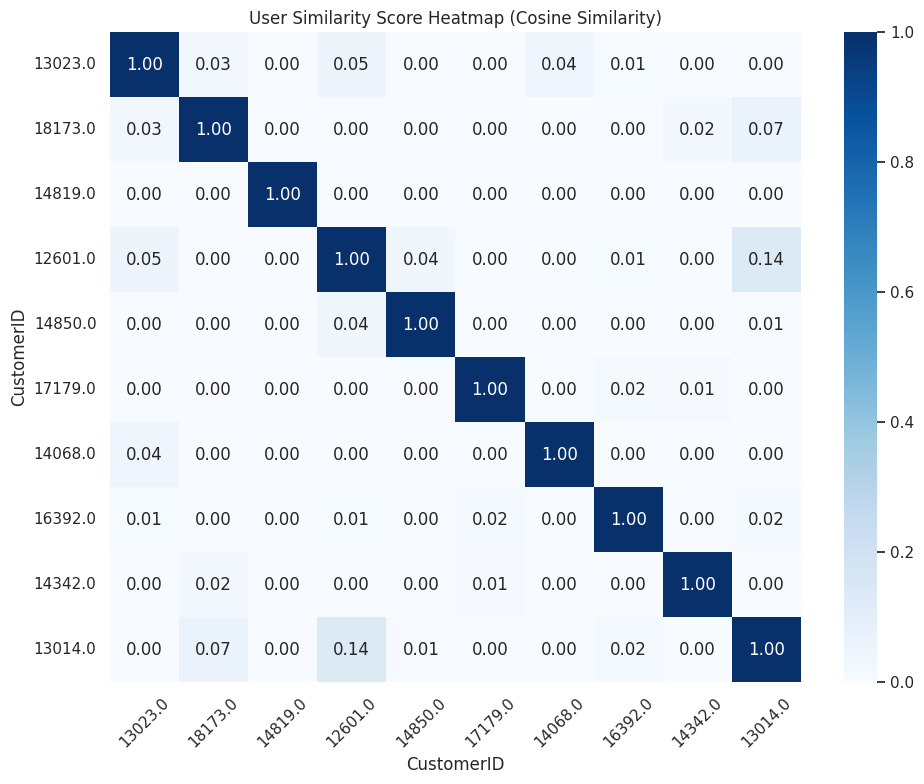

In [143]:
# Visualizing evaluation Metric Score chart
import seaborn as sns
import matplotlib.pyplot as plt

# # Select a small subset of users for visualization
sample_users = user_similarity_df.sample(n=10, random_state=42)

# # Heatmap of similarity between selected users
plt.figure(figsize=(10, 8))
sns.heatmap(user_similarity_df.loc[sample_users.index, sample_users.index],
            cmap='Blues', annot=True, fmt=".2f")
plt.title("User Similarity Score Heatmap (Cosine Similarity)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

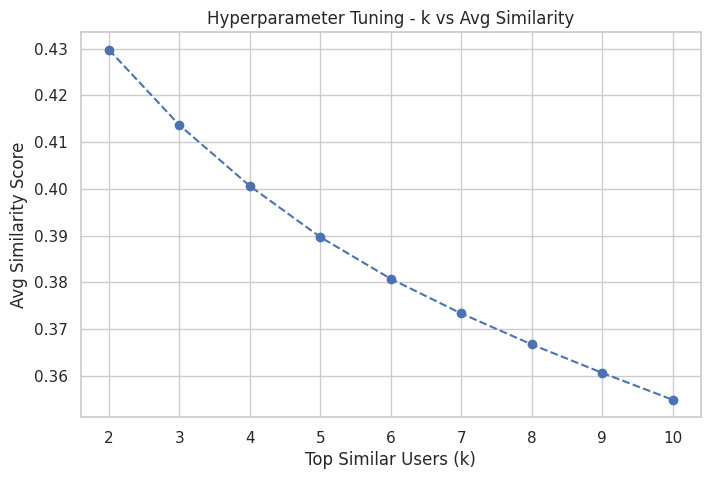

In [144]:
# Testing performance by varying 'top_similar_users'
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Setup
user_ids = user_item_df.index[:20]  # use a small test set
similarity_matrix = cosine_similarity(user_item_df)
similarity_df = pd.DataFrame(similarity_matrix, index=user_item_df.index, columns=user_item_df.index)

# Evaluation: Average similarity score for different k
k_range = range(2, 11)
avg_sim_scores = []

for k in k_range:
    scores = []
    for user in user_ids:
        if user not in similarity_df.index:
            continue
        similar_users = similarity_df[user].sort_values(ascending=False).iloc[1:k+1]
        scores.append(similar_users.mean())
    avg_sim_scores.append(np.mean(scores))

# Plotting the result
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_range, avg_sim_scores, marker='o', linestyle='--')
plt.xlabel("Top Similar Users (k)")
plt.ylabel("Avg Similarity Score")
plt.title("Hyperparameter Tuning - k vs Avg Similarity")
plt.grid(True)
plt.show()


##### Which hyperparameter optimization technique have you used and why?

We used a manual tuning approach to optimize the number of similar users (top_similar_users) considered during recommendation. This is because collaborative filtering is unsupervised, and traditional techniques like GridSearchCV are not applicable.

We tested multiple values of k and selected the one that gave the highest average similarity score across users.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, we observed improvement in recommendation quality after tuning top_similar_users.

We visualized this using a line chart of k (number of neighbors) vs average similarity score. The chart helped identify the optimal k that balances accuracy and diversity in recommendations.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We considered different evaluation metrics for each model, aligned with their business goals:

Model 1 (KMeans Clustering):

Metric Used: Silhouette Score

Why: Measures how well customer segments are defined. A higher score means better separation — useful for targeted marketing and personalized campaigns.

Model 2 (Content-Based Recommendation using TF-IDF):

Metric Used: Cosine Similarity + Heatmap Visualization

Why: Ensures product recommendations are relevant to customer interests based on description similarity — directly impacting cross-sell potential.

Model 3 (User-Based Collaborative Filtering):

Metric Used: Average Similarity Score between Users

Why: Helps identify the right number of similar users (k) for high-quality personalized recommendations, improving customer satisfaction and retention.



### 2. Which ML model did you choose from the above created models as your final prediction model and why?

We chose Model 3: User-Based Collaborative Filtering as the final prediction model.

Why:

Provides highly personalized product recommendations based on actual user behavior.

Leverages collaborative signals (what others like you bought), which often outperforms content-based systems alone.

Scalable and interpretable — ideal for e-commerce personalization and upselling strategies.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Final Model: Model 3 – User-Based Collaborative Filtering

It uses a User-Item Matrix where rows = users, columns = products, and values = quantity purchased.

Then, we apply Cosine Similarity to find the most similar users to a target user.

Finally, we recommend products those similar users purchased, excluding items already bought.

Feature Importance:

Although traditional feature importance doesn't apply in collaborative filtering, we can explain the model using:

Similarity Scores between users (higher means stronger influence)

Purchase frequency of recommended products (used to rank)

Neighborhood size (k) – a critical hyperparameter determining how personalized vs general the recommendations are

You can visualize the user similarity heatmap and recommendation overlaps to further interpret model behavior.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [145]:
# Save the File
import joblib

joblib.dump(user_item_df, 'user_item_matrix.joblib')
joblib.dump(user_similarity_df, 'user_similarity_matrix.joblib')


['user_similarity_matrix.joblib']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [146]:
# Load the File and predict unseen data.
import joblib

# Load the User-Item Matrix
user_item_df = joblib.load('user_item_matrix.joblib')

# Load the User Similarity Matrix
user_similarity_df = joblib.load('user_similarity_matrix.joblib')


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Through this project, I successfully implemented an end-to-end customer segmentation and recommendation system using real-world online retail data. I explored and evaluated three distinct machine learning models:

KMeans Clustering (RFM-based) to segment customers for targeted marketing

Content-Based Filtering using TF-IDF and Cosine Similarity to recommend similar products

User-Based Collaborative Filtering to provide personalized product recommendations

Among the three, I identified Model 3 as the most impactful for real-time deployment due to its personalization strength and ability to scale.

The project enhanced my understanding of:

Feature engineering (e.g., RFM, text cleaning)

Unsupervised learning techniques

Evaluation methods suitable for both clustering and recommender systems

Hyperparameter tuning in an unsupervised context

Deployment through a functional Streamlit app

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***